In [200]:
# =========================
# Imports
# =========================
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import snowflake.connector
from sklearn.metrics import mean_absolute_error
import seaborn as sns
from dotenv import load_dotenv
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import numpy as np
from sklearn.impute import SimpleImputer








from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


In [201]:


load_dotenv()  
conn = snowflake.connector.connect(
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema="GOLD",
)

print("✅ Connexion Snowflake via .env OK")


✅ Connexion Snowflake via .env OK


In [202]:
query = """
SELECT f.*, d.latitude, d.longitude
FROM GOLD.FUSION_AQICN_WEATHER f
LEFT JOIN SILVER.DIM_CITY d
    ON f.city_id = d.city_id
"""

df = pd.read_sql(query, conn)

print("df:", df.shape)
df.head()

/var/folders/tv/lm4xf58100z0w350rlffy8fr0000gn/T/ipykernel_44385/2921909470.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


df: (101326, 44)


,CITY_ID,DT_HOUR,TEMPERATURE,HUMIDITY,WIND_SPEED,VISIBILITY,IAQI_PM10,IAQI_PM25,IAQI_PRESSURE,IAQI_O3,...,HUM_LAG_48,WIND_LAG_48,VISIBILITY_LAG_48,PM10_LAG_48,PM25_LAG_48,PRESSURE_LAG_48,O3_LAG_48,AQI_LAG_48,LATITUDE,LONGITUDE
0,53c3818ae1e39e99e475c64444ba3fb6,2021-11-06 07:00:00+00:00,NaN,NaN,NaN,NaN,21.0,38.0,NaN,17.0,...,NaN,NaN,NaN,12.0,10.0,NaN,21.0,30.0,43.1249,5.9347
1,53c3818ae1e39e99e475c64444ba3fb6,2021-11-07 07:00:00+00:00,NaN,NaN,NaN,NaN,25.0,51.0,NaN,10.0,...,NaN,NaN,NaN,18.0,17.0,NaN,17.0,21.0,43.1249,5.9347
2,53c3818ae1e39e99e475c64444ba3fb6,2021-11-08 08:00:00+00:00,NaN,NaN,NaN,NaN,23.0,51.0,NaN,31.0,...,NaN,NaN,NaN,21.0,38.0,NaN,10.0,38.0,43.1249,5.9347
3,53c3818ae1e39e99e475c64444ba3fb6,2021-11-09 08:00:00+00:00,NaN,NaN,NaN,NaN,13.0,38.0,NaN,29.0,...,NaN,NaN,NaN,25.0,51.0,NaN,31.0,51.0,43.1249,5.9347
4,53c3818ae1e39e99e475c64444ba3fb6,2021-11-10 08:00:00+00:00,NaN,NaN,NaN,NaN,14.0,24.0,NaN,31.0,...,NaN,NaN,NaN,23.0,51.0,NaN,29.0,51.0,43.1249,5.9347


In [203]:
# --- Nettoyage + datetime ---
df.columns = [c.lower() for c in df.columns]
df["dt_hour"] = pd.to_datetime(df["dt_hour"], errors="coerce")
df = df[df["dt_hour"].notna()].copy()

# --- Features temps ---
df["month"] = df["dt_hour"].dt.month
df["day_of_week"] = df["dt_hour"].dt.dayofweek
df["hour"] = df["dt_hour"].dt.hour

print(df.shape)
df[["city_id","dt_hour","month","day_of_week","hour","latitude","longitude"]].head()

(101326, 47)


,city_id,dt_hour,month,day_of_week,hour,latitude,longitude
0,53c3818ae1e39e99e475c64444ba3fb6,2021-11-06 07:00:00+00:00,11,5,7,43.1249,5.9347
1,53c3818ae1e39e99e475c64444ba3fb6,2021-11-07 07:00:00+00:00,11,6,7,43.1249,5.9347
2,53c3818ae1e39e99e475c64444ba3fb6,2021-11-08 08:00:00+00:00,11,0,8,43.1249,5.9347
3,53c3818ae1e39e99e475c64444ba3fb6,2021-11-09 08:00:00+00:00,11,1,8,43.1249,5.9347
4,53c3818ae1e39e99e475c64444ba3fb6,2021-11-10 08:00:00+00:00,11,2,8,43.1249,5.9347


In [171]:
print(df.columns)
print("Shape df:", df.shape)

Index(['city_id', 'dt_hour', 'temperature', 'humidity', 'wind_speed',
       'visibility', 'iaqi_pm10', 'iaqi_pm25', 'iaqi_pressure', 'iaqi_o3',
       'aqi', 'current_health_risk_score', 'risk_score_lag_12', 'temp_lag_12',
       'hum_lag_12', 'wind_lag_12', 'visibility_lag_12', 'pm10_lag_12',
       'pm25_lag_12', 'pressure_lag_12', 'o3_lag_12', 'aqi_lag_12',
       'risk_score_lag_24', 'temp_lag_24', 'hum_lag_24', 'wind_lag_24',
       'visibility_lag_24', 'pm10_lag_24', 'pm25_lag_24', 'pressure_lag_24',
       'o3_lag_24', 'aqi_lag_24', 'risk_score_lag_48', 'temp_lag_48',
       'hum_lag_48', 'wind_lag_48', 'visibility_lag_48', 'pm10_lag_48',
       'pm25_lag_48', 'pressure_lag_48', 'o3_lag_48', 'aqi_lag_48', 'latitude',
       'longitude', 'month', 'day_of_week', 'hour'],
      dtype='object')
Shape df: (101326, 47)


In [165]:
# # Trier correctement
# df = df.sort_values(["city_id", "dt_hour"]).copy()

# # Calculer la différence entre timestamps consécutifs par ville
# df["delta_time"] = df.groupby("city_id")["dt_hour"].diff()

# # Voir la distribution des écarts
# df["delta_time"].value_counts().head(20)

delta_time
1 days 00:00:00    71509
0 days 01:00:00    14853
0 days 00:00:00    13421
1 days 01:00:00      195
0 days 23:00:00      193
0 days 02:00:00      183
0 days 04:00:00      131
2 days 00:00:00      129
0 days 03:00:00      103
3 days 00:00:00       78
0 days 05:00:00       70
0 days 06:00:00       48
0 days 12:00:00       44
0 days 07:00:00       43
0 days 09:00:00       34
0 days 08:00:00       32
0 days 11:00:00       30
0 days 13:00:00       29
4 days 00:00:00       20
5 days 00:00:00       19
Name: count, dtype: int64

In [204]:
df = df[df["dt_hour"] >= "2025-12-12"].copy()

In [205]:
df["delta_time"] = df.groupby("city_id")["dt_hour"].diff()
df["delta_time"].value_counts()

delta_time
0 days 01:00:00     14853
0 days 00:00:00     13421
1 days 00:00:00       577
0 days 02:00:00       175
0 days 04:00:00       129
0 days 03:00:00        98
0 days 05:00:00        70
0 days 06:00:00        45
0 days 12:00:00        44
0 days 07:00:00        40
0 days 11:00:00        30
0 days 08:00:00        27
0 days 09:00:00        26
0 days 13:00:00        17
3 days 00:00:00        16
0 days 10:00:00        13
0 days 16:00:00        11
0 days 17:00:00        10
0 days 18:00:00         8
3 days 18:00:00         3
0 days 15:00:00         3
3 days 19:00:00         2
3 days 21:00:00         2
1 days 08:00:00         2
24 days 05:00:00        2
0 days 19:00:00         2
1 days 10:00:00         1
9 days 12:00:00         1
3 days 20:00:00         1
24 days 06:00:00        1
24 days 07:00:00        1
9 days 13:00:00         1
1 days 11:00:00         1
9 days 18:00:00         1
0 days 14:00:00         1
2 days 12:00:00         1
9 days 11:00:00         1
Name: count, dtype: int64

In [206]:
df[df["dt_hour"] >= "2025-12-12"].shape

(29658, 48)

In [207]:
df = df[df["dt_hour"] >= "2025-12-12"].copy()

In [210]:
df = (
    df.groupby(["city_id", "dt_hour"], as_index=False)
      .mean()
)

In [211]:
df = df.sort_values(["city_id", "dt_hour"])
df["delta_time"] = df.groupby("city_id")["dt_hour"].diff()
df["delta_time"].value_counts().head()

delta_time
0 days 01:00:00    14853
1 days 00:00:00      577
0 days 02:00:00      175
0 days 04:00:00      129
0 days 03:00:00       98
Name: count, dtype: int64

In [213]:
df["aqi_lead_12"] = df.groupby("city_id")["aqi"].shift(-12)
df["aqi_lead_24"] = df.groupby("city_id")["aqi"].shift(-24)
df["aqi_lead_48"] = df.groupby("city_id")["aqi"].shift(-48)

print(df[["aqi_lead_12","aqi_lead_24","aqi_lead_48"]].isna().sum())

aqi_lead_12    2784
aqi_lead_24    3003
aqi_lead_48    3438
dtype: int64


In [214]:
df_12 = df[df["aqi_lead_12"].notna()].copy()
print("Shape pour 12h :", df_12.shape)

Shape pour 12h : (13453, 51)


In [215]:
df.columns

Index(['city_id', 'dt_hour', 'temperature', 'humidity', 'wind_speed',
       'visibility', 'iaqi_pm10', 'iaqi_pm25', 'iaqi_pressure', 'iaqi_o3',
       'aqi', 'current_health_risk_score', 'risk_score_lag_12', 'temp_lag_12',
       'hum_lag_12', 'wind_lag_12', 'visibility_lag_12', 'pm10_lag_12',
       'pm25_lag_12', 'pressure_lag_12', 'o3_lag_12', 'aqi_lag_12',
       'risk_score_lag_24', 'temp_lag_24', 'hum_lag_24', 'wind_lag_24',
       'visibility_lag_24', 'pm10_lag_24', 'pm25_lag_24', 'pressure_lag_24',
       'o3_lag_24', 'aqi_lag_24', 'risk_score_lag_48', 'temp_lag_48',
       'hum_lag_48', 'wind_lag_48', 'visibility_lag_48', 'pm10_lag_48',
       'pm25_lag_48', 'pressure_lag_48', 'o3_lag_48', 'aqi_lag_48', 'latitude',
       'longitude', 'month', 'day_of_week', 'hour', 'delta_time',
       'aqi_lead_12', 'aqi_lead_24', 'aqi_lead_48'],
      dtype='object')

aqi_lead_12                  1.000000
aqi_lag_12                   0.447664
aqi                          0.415900
aqi_lead_24                  0.413334
aqi_lag_24                   0.331964
risk_score_lag_12            0.330353
current_health_risk_score    0.305298
aqi_lead_48                  0.299438
aqi_lag_48                   0.273815
month                        0.225427
risk_score_lag_24            0.212159
iaqi_pressure                0.208982
longitude                   -0.195085
pressure_lag_12              0.189702
temp_lag_48                  0.156938
risk_score_lag_48            0.148839
pressure_lag_24              0.143367
temp_lag_24                  0.123997
hour                         0.117971
pm25_lag_12                  0.116113
Name: aqi_lead_12, dtype: float64


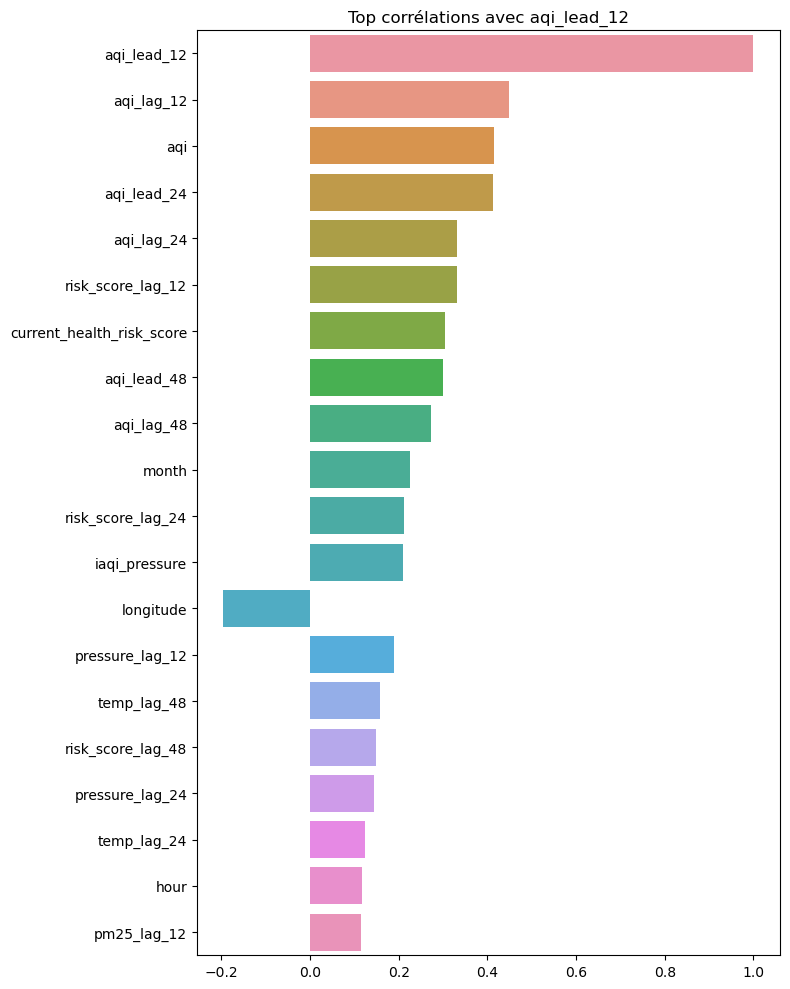

In [216]:
import matplotlib.pyplot as plt
import seaborn as sns

TARGET = "aqi_lead_12"

# garder seulement numérique
df_corr = df.select_dtypes(include=["float64","int64"]).copy()

# supprimer lignes où target est NaN
df_corr = df_corr[df_corr[TARGET].notna()]

# corrélation avec target
corr_series = df_corr.corr()[TARGET].sort_values(key=abs, ascending=False)

print(corr_series.head(20))

plt.figure(figsize=(8,10))
sns.barplot(
    x=corr_series.head(20).values,
    y=corr_series.head(20).index
)
plt.title("Top corrélations avec aqi_lead_12")
plt.tight_layout()
plt.show()

In [218]:
TARGET = "aqi_lead_12"

selected_features = [
    "aqi","aqi_lag_12","aqi_lag_24","aqi_lag_48",
    "iaqi_pm10","pm10_lag_12","pm10_lag_24","pm10_lag_48,"
    "iaqi_pm25","pm25_lag_12","pm25_lag_24","pm25_lag_48",
    "iaqi_o3","o3_lag_12","o3_lag_24","o3_lag_48",
    "month",
    "day_of_week",
    "hour"
]
selected_features = [c for c in selected_features if c in df.columns]

df_model_aqi_12 = df[selected_features + [TARGET]].dropna(subset=[TARGET]).copy()

print(df_model_aqi_12.shape)
print("Nb features:", len(selected_features))

(13453, 18)
Nb features: 17


In [219]:
TEST_SIZE = 0.2

LINEAR_MODELS = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0, random_state=42),
}

TREE_MODELS = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=600,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

def run_benchmark(df_model, target):
    
    dfm = df_model.dropna(subset=[target]).copy()
    
    X = dfm.drop(columns=[target])
    y = dfm[target]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        shuffle=False
    )
    
    # Préprocessing pour modèles linéaires
    preprocess_linear = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                list(X.columns),
            )
        ],
        remainder="drop",
    )
    
    # Préprocessing pour modèles arbres
    preprocess_tree = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                ]),
                list(X.columns),
            )
        ],
        remainder="drop",
    )
    
    scores = {}
    trained_models = {}
    
    # Modèles linéaires
    for name, model in LINEAR_MODELS.items():
        
        pipe = Pipeline([
            ("preprocess", preprocess_linear),
            ("model", clone(model)),
        ])
        
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        
        scores[name] = {
            "MAE": float(mean_absolute_error(y_test, pred)),
            "RMSE": float(np.sqrt(mean_squared_error(y_test, pred))),
            "R2": float(r2_score(y_test, pred)),
        }
        
        trained_models[name] = pipe
    
    # Modèles arbres
    for name, model in TREE_MODELS.items():
        
        pipe = Pipeline([
            ("preprocess", preprocess_tree),
            ("model", clone(model)),
        ])
        
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        
        scores[name] = {
            "MAE": float(mean_absolute_error(y_test, pred)),
            "RMSE": float(np.sqrt(mean_squared_error(y_test, pred))),
            "R2": float(r2_score(y_test, pred)),
        }
        
        trained_models[name] = pipe
    
    best_name = min(scores, key=lambda k: scores[k]["RMSE"])
    
    return scores, best_name, trained_models[best_name]

In [220]:
scores_12, best_12, model_12 = run_benchmark(df_model_aqi_12, TARGET)

print("Best model:", best_12)
pd.DataFrame(scores_12).T.sort_values("RMSE")

Best model: GradientBoosting


,MAE,RMSE,R2
GradientBoosting,11.625893,15.797962,0.178314
RandomForest,12.070670,16.330565,0.121976
DecisionTree,17.722346,24.264583,-0.938428
Ridge,15.984962,32.548963,-2.488014
LinearRegression,15.985719,32.552006,-2.488667


In [194]:

importances = model_12.named_steps["model"].feature_importances_
features = df_model_aqi_12.drop(columns=[TARGET]).columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
1,aqi_lag_12,0.292162
0,aqi,0.244792
16,hour,0.083422
2,aqi_lag_24,0.080271
14,month,0.061337
15,day_of_week,0.039682
4,iaqi_pm10,0.034824
3,aqi_lag_48,0.028249
8,pm25_lag_24,0.028133
11,o3_lag_12,0.022814


In [221]:
TARGET = "aqi_lead_24"

df_model_aqi_24 = df[selected_features + [TARGET]].dropna(subset=[TARGET]).copy()

scores_24, best_24, model_24 = run_benchmark(df_model_aqi_24, TARGET)

print("Best model 24h:", best_24)
pd.DataFrame(scores_24).T.sort_values("RMSE")

Best model 24h: GradientBoosting


,MAE,RMSE,R2
GradientBoosting,11.933916,16.081362,0.138112
RandomForest,12.126532,16.256915,0.119191
DecisionTree,17.285512,23.611774,-0.858072
Ridge,16.322581,32.467385,-2.513176
LinearRegression,16.323387,32.471417,-2.514049


In [222]:
TARGET = "aqi_lead_48"

df_model_aqi_48 = df[selected_features + [TARGET]].dropna(subset=[TARGET]).copy()

scores_48, best_48, model_48 = run_benchmark(df_model_aqi_48, TARGET)

print("Best model 48h:", best_48)
pd.DataFrame(scores_48).T.sort_values("RMSE")

Best model 48h: GradientBoosting


,MAE,RMSE,R2
GradientBoosting,12.000499,16.310075,0.062432
RandomForest,12.278636,16.404853,0.051504
DecisionTree,16.665169,22.126585,-0.725518
Ridge,18.379042,44.247501,-5.900305
LinearRegression,18.391115,44.334477,-5.927459
